In [1]:
from wrapper import BasicEnvironmentRGB
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, AddRenderObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
import numpy as np
import torch
import skdim

framestack = 1
latent_size = 8192
obs_shape = 128
steps = 5000
l1_coeff = 0
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=steps)

In [2]:
obs, _ = env.reset()
# plt.imshow(obs[3:, :, :,].transpose(1, 2, 0))

In [3]:
obs, _, _, _, _ = env.step(2)
# plt.imshow(obs)

In [4]:
samples = random_sample_single_env(env, num_steps=steps)
for i in range(steps):
    buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

In [5]:
from fundamental_variable_discovery import Encoder, Decoder

encoder = Encoder(framestack, latent_size, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_size).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-5)


In [6]:
losses = []
for i in range(10000):
    if i % 1000 == 0:
        print(i)
    samples = buffer.sample(128)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255 - 0.5).cuda()
    latent = encoder(obs)
    reconstruction = decoder(latent)
    loss = torch.nn.functional.mse_loss(reconstruction, obs + 0.5) + torch.norm(latent, p=1, dim=-1).mean() * l1_coeff
    loss.backward()
    opt.step()
    opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())

0
1000
2000
3000
4000
5000
6000
7000
8000
9000


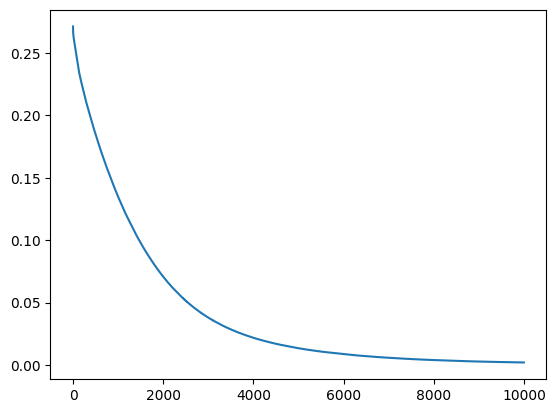

In [7]:
plt.plot(losses)

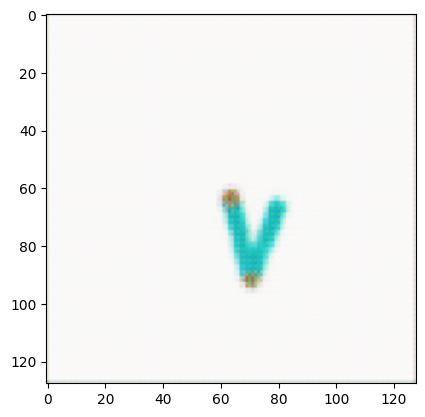

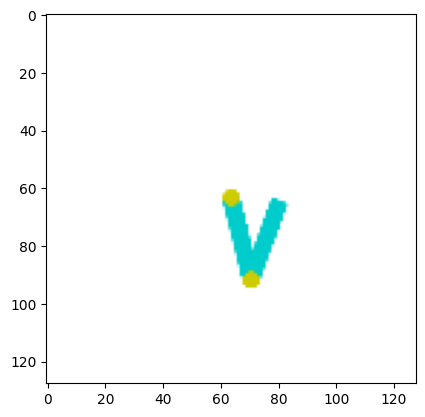

In [8]:
plt.imshow(reconstruction[0].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
plt.show()
plt.imshow(samples[0][0][:, :, :3])

In [9]:
latent_ID = []
image_ID = []

for _ in range(10):
    samples = buffer.sample(128)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255 - 0.5).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 5.93294512866879 +- 0.2759437665862807
Image ID: 6.486354683080611 +- 0.31160514531421896
